# Implementation og K-Means cluster

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples = 1000, centers = 3, n_features = 2, random_state =23)

In [3]:
X.shape

(1000, 2)

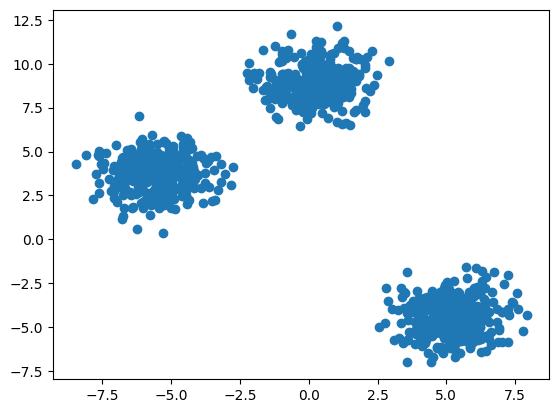

In [4]:
plt.scatter(X[:,0],X[:,1])
plt.show()
#c=y give color to chart

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.33, random_state = 42)

In [6]:
from sklearn.cluster import KMeans

# Elbow methods

In [7]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [8]:
wcss

[34827.57682552023,
 7935.437286145421,
 1319.2730531585605,
 1140.4677884655127,
 1036.6197968584806,
 955.3419787874734,
 760.9245008463125,
 685.7474256647753,
 581.9398706211474,
 546.8559221936471]

# Plot elbow method

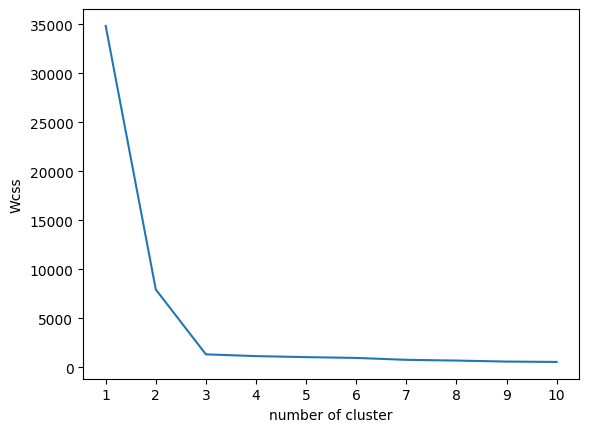

In [9]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of cluster")
plt.ylabel("Wcss")
plt.show()

In [10]:
kmeans = KMeans(n_clusters = k, init = 'k-means++')

In [11]:
y_labels = kmeans.fit_predict(X_train)
#fit predict is for training data

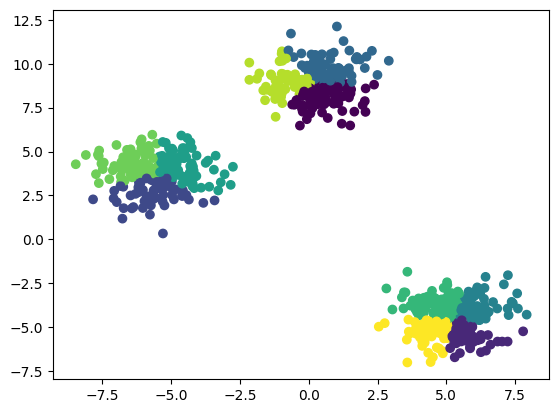

In [12]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_labels)
plt.show()

In [13]:
y_test_label = kmeans.predict(X_test)

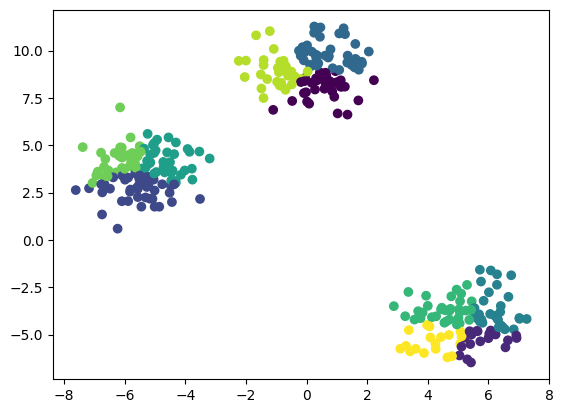

In [14]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_test_label)
plt.show()

# Knee locator

In [15]:
!pip install kneed


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [17]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

# Performance metrics

In [19]:
from sklearn.metrics import silhouette_score

In [21]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, init='k-means++')
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [22]:
silhouette_coefficients 

[0.7281443868598331,
 0.8071181203797673,
 0.6395232326323956,
 0.49134355005793406,
 0.46410342499135815,
 0.47564388759837944,
 0.46122869024542185,
 0.32420173064953006,
 0.3226604816424214]

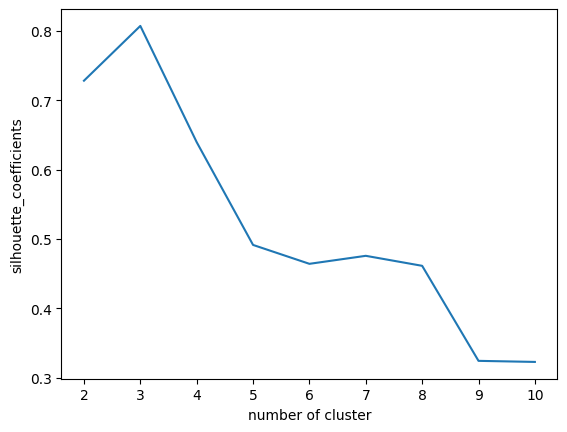

In [24]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("number of cluster")
plt.ylabel("silhouette_coefficients")
plt.show()
# 3 has highest silhouette score